# Approche Deep Learning (YOLO, ResNet)

### Importation des bibliothèques

In [1]:
# Bibliothèques nécessaires
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
import sys
from PIL import Image

# Pour la détection avec YOLOv8
from ultralytics import YOLO

# Pour la classification avec ResNet-18
import torch
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report

# Ajoute explicitement le dossier src au chemin Python
sys.path.append('../src')

# Importation des fonctions depuis le module local src/utils.py
from utils import (
    init_lists_1,
    calculate_iou,
    train_resnet,
    predict_and_display_image,
    evaluate_full_test_set
)

# Assurer la reproduction des résultats
random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

### Initialisation des listes

Pour nous simplifier la lecture des fichiers (images et labels), on crée une liste qui référence tous les chemins relatifs aux images selon l'arborescence et une autre liste qui prendra les contenus des textes associés aux images. Ils auront alors les mêmes indices.

In [2]:
# Initialisation des listes
im_add_train, labels_train = init_lists_1(train=True)
im_add_val, labels_val = init_lists_1(train = False)

# On créera une liste de cardinaux à partir des véritables étiquettes (GT_card) pour faciliter la lecture des résultats
dict_card_fr = {0: "EST", 1: "NORD", 2: "SUD", 3: "OUEST"} 

# Vérification : On doit avoir 168 (sauf si on ne compte pas le fichier en .gif qui est illisible donc 167) adresses d'images et listes de labels 
print(f"On a {len(im_add_train)} adresses d'images et {len(labels_train)} listes de labels pour l'entraînement.")
print(f"On a {len(im_add_val)} adresses d'images et {len(labels_val)} listes de labels pour la validation.")
print(f"On a alors {len(im_add_train)+len(im_add_val)} adresses d'images et {len(labels_train)+len(labels_val)} listes de labels au total.")

On a 133 adresses d'images et 133 listes de labels pour l'entraînement.
On a 34 adresses d'images et 34 listes de labels pour la validation.
On a alors 167 adresses d'images et 167 listes de labels au total.


### Détection : YOLO

Pour la détection de bouée pour l'approche Deep Learning, nous décidons de nous inspirer du Tutoriel 13 du module "Advanced Deep Learning" du bloc "Image Science (1)" en utilisant la méthode de fine-tune de YOLO sur le nouveau dataset.

Pour information, notre arborescence ressemble à cela

```
buoys0/
├── images/
│   ├── train/
│   ├── val/
├── labels/
│   ├── train/
│   ├── val/
├── buoys0.yaml

```
où la répartition des images est {train : 0.7, val : 0.3}.

In [3]:
# Choix d'une image aléatoire
ALEATOIRE = False
if ALEATOIRE :
    c = random.randint(0, len(im_add_train) - 1)
else : c = 6

adresse_img, liste = im_add_train[c], labels_train[c]
print(f"On a choisi l'image d'entraînement numéro   : {c}")

# Liste des coordonnées de type [xmin, ymin, xmax, ymax]
print(f"La bounding box de la bouée est situé en    : [xmin, ymin, xmax, ymax] = {liste[1:]}")
print(f"Son adresse est                             : {adresse_img}")

On a choisi l'image d'entraînement numéro   : 6
La bounding box de la bouée est situé en    : [xmin, ymin, xmax, ymax] = [117, 47, 617, 909]
Son adresse est                             : ../datasets/buoys0/images/train/E_007.jpg


On a commenté cette partie car on n'a pas besoin de le re-entraîné comme on l'importe dans la cellule suivante.

In [4]:
# # Fine-tuning du modèle YOLOv8n pré-entraîné sur le dataset de bouées

# # Chargement du modèle pré-entraîné sur COCO de YOLOv8n
# modelft = YOLO("yolov8n.pt")

# # Entraînement du modèle sur le dataset de bouées
# results = modelft.train(
#     data= "../datasets/buoys0/buoys0.yaml",  
#     epochs= 3,  
#     batch = 16,
#     imgsz= 640,
#     lr0 = 0.001,
#     optimizer = "Adam",
#     resume=False
# )


0: 640x480 1 buoy, 47.6ms
Speed: 20.6ms preprocess, 47.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)


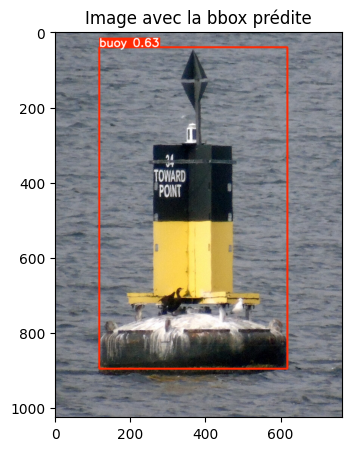

In [5]:
# Chargement du meilleur modèle après l'entraînement
MODEL_ROOT = "../weights/best.pt"

modelft=YOLO(MODEL_ROOT)

# Test du modèle fine-tuné sur une image et affichage des résultats
image = cv2.imread(adresse_img)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Visualisation des résultats de la détection avec YOLOv8
res = modelft(image, conf = 0.02)

for result in res :
    im = result.plot()
    plt.figure(figsize= (10,5))
    plt.imshow(im)
    #plt.axis('off')
    plt.title("Image avec la bbox prédite")
    plt.show()

### Statistiques de la détection

On calcule dans cette partie les métriques liées à la détection c'est-à-dire la moyenne des IoU de chaque image où l'IoU est définie par 
$$ IoU = \frac{\text{Intersection des aires des bounding boxes}}{\text{Union des aires des bounding boxes}} $$

Comme nos données ont un seuil de confiance bas pour favoriser la détection, au lieu de calculer le mAP (mean Average Precision), nous calculons le mAP @ 50 que l'on va définir de façon plus facile par : $$ \text{mAP @ 0.50} = \frac{1}{N} \sum_{i = 1}^{N} \mathbb{1}_{\text{IoU}_i > 0.5} $$ 

Test de détection sur l'image ../datasets/buoys0/images/train/E_007.jpg


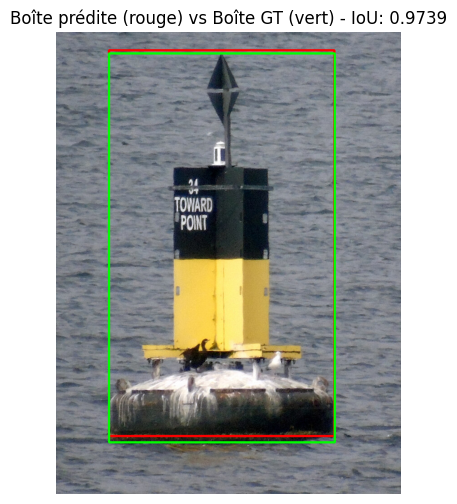

In [6]:
# Cellule de test pour visualiser les étapes de détection avec une image ciblée
adresse_test = adresse_img
gt_test = liste[1:]

print(f"Test de détection sur l'image {adresse_test}")
pred_test = res[0].boxes.xyxy.cpu().numpy()[0].astype(int)

# Calcul de l'IoU entre la boîte prédite et la boîte GT
iou = calculate_iou(pred_test, liste[1:])
img_draw = image.copy()

cv2.rectangle(img_draw, (pred_test[0], pred_test[1]), (pred_test[2], pred_test[3]), (255, 0, 0), 4) # Boîte prédite en rouge
cv2.rectangle(img_draw, (liste[1], liste[2]), (liste[3], liste[4]), (0, 255, 0), 4) # Boîte GT en vert
plt.figure(figsize=(8, 6))
plt.imshow(img_draw)
plt.title(f"Boîte prédite (rouge) vs Boîte GT (vert) - IoU: {iou:.4f}")
plt.axis("off")
plt.show()

In [7]:
bbox_predicted = []

for address in im_add_val:
    image = cv2.imread(address)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    res = modelft(image, conf = 0.02);
    boite = res[0].boxes.xyxy.cpu().numpy().tolist();
    if len(boite) == 0:
        boite = [[0,0,0,0]]
    bbox_predicted.append(boite[0])


0: 512x640 1 buoy, 50.4ms
Speed: 1.7ms preprocess, 50.4ms inference, 0.8ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 buoy, 44.3ms
Speed: 1.1ms preprocess, 44.3ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 buoy, 41.0ms
Speed: 1.6ms preprocess, 41.0ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 buoy, 39.7ms
Speed: 1.6ms preprocess, 39.7ms inference, 0.9ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 buoy, 41.5ms
Speed: 1.0ms preprocess, 41.5ms inference, 0.9ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 buoy, 36.5ms
Speed: 0.9ms preprocess, 36.5ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 buoy, 35.9ms
Speed: 1.4ms preprocess, 35.9ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 640)

0: 640x544 (no detections), 53.1ms
Speed: 1.9ms preprocess, 53.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 544)

In [8]:
# Run evaluation
all_ious = [calculate_iou(bbox_predicted[i], labels_val[i][1:]) for i in range(len(im_add_val))]
print(f"\nMétriques sur {len(im_add_val)} images:")
print(f"Mean IoU: {np.mean(all_ious):.4f}")
print(f"mAP @ 0.5: {np.mean([1 if iou > 0.5 else 0 for iou in all_ious]):.4f}")


Métriques sur 34 images:
Mean IoU: 0.7009
mAP @ 0.5: 0.7647


Cette moyenne d'IoU est très satisfaisante pour la rapidité de l'algorithme.

On teste l'algorithme sur une image aléatoire du dataset d'évaluation (où le modèle n'a pas été entraîné). On affiche aussi les bounding boxes prédites et celle de la vérité terrain.

Test de détection sur l'image index 1 : ../datasets/buoys0/images/val/E_031.jpg


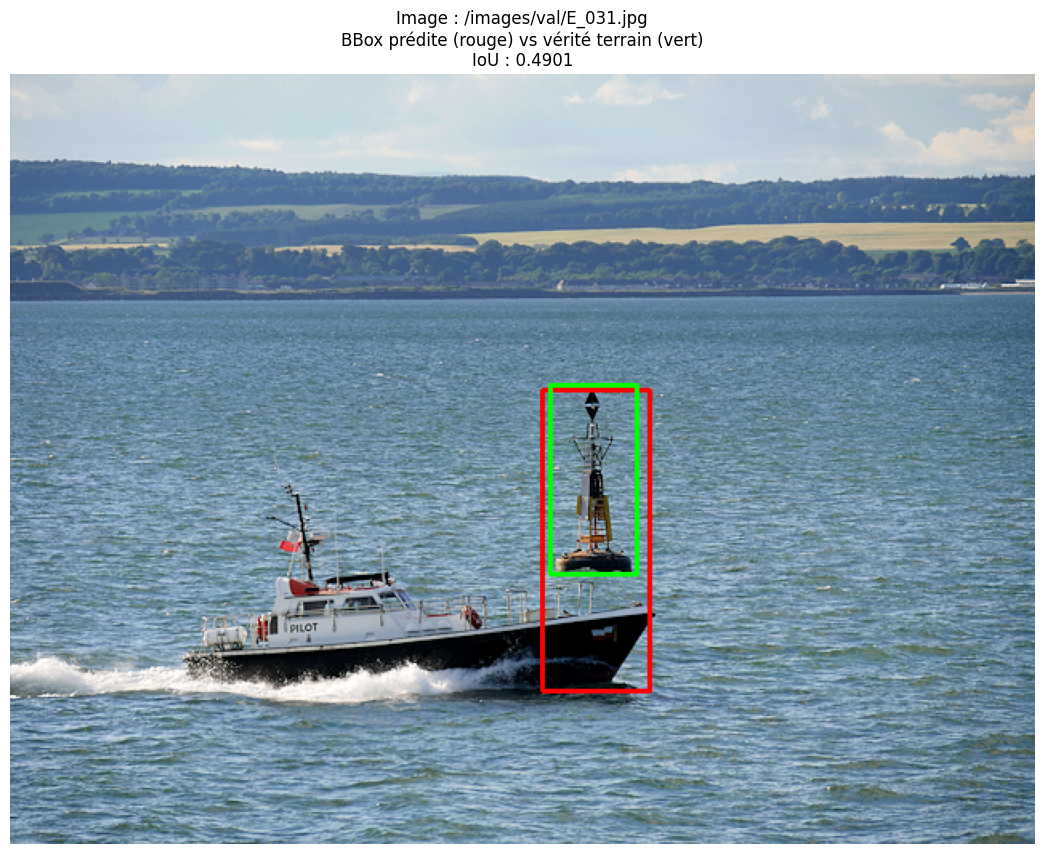

In [9]:
# Cellule de test unitaire pour visualiser les étapes de détection
test_index = random.randint(0, len(im_add_val) - 1)

adresse_test = im_add_val[test_index]
gt_test = [int(v) for v in labels_val[test_index][1:]]

print(f"Test de détection sur l'image index {test_index} : {adresse_test}")
pred_test = [int(v) for v in bbox_predicted[test_index]]

iou_test = calculate_iou(pred_test, gt_test)

presence_bbox = (True if iou_test > 0 else False)

image = cv2.imread(adresse_test)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Dessin des deux boîtes sur la même image
image_vis = image.copy()
px1, py1, px2, py2 = pred_test
gx1, gy1, gx2, gy2 = gt_test

# Prédiction en rouge
cv2.rectangle(image_vis, (px1, py1), (px2, py2), (255, 0, 0), 2)
# Vérité terrain en vert
cv2.rectangle(image_vis, (gx1, gy1), (gx2, gy2), (0, 255, 0), 2)

plt.figure(figsize=(15, 10))
plt.imshow(image_vis)
plt.axis('off')
plt.title(f"Image : {adresse_test[18:]}\nBBox prédite (rouge) vs vérité terrain (vert)\nIoU : {iou_test:.4f}" if presence_bbox else f"Image : {adresse_test[18:]}\nPas de bbox prédite, vérité terrain en vert")
plt.show()

### Classification : ResNet

En testant la classification avec le modèle de YOLO, il était difficile d'avoir de bons résultats, c'est pourquoi nous allons utiliser un autre modèle pour cette partie.

Pour la classification, nous allons nous inspirer de la partie 3 du Lab10_XAI du module "Advanced Deep Learning" du bloc "Data Science (1)" qui consiste à fine-tune un réseau pré-entraîné ResNet-18 et à l'adapter à notre dataset.

Pour entraîner le ResNet-18, nous utilisons le fichier "dataset2" dont l'arborescence ressemble à cela

```
dataset2/
├── train/
│   ├── class1/
│   ├── class2/
│   ├── ...
├── val/
│   ├── class1/
│   ├── class2/
│   ├── ...
├── test/
│   ├── class1/
│   ├── class2/
│   ├── ...

```
où les classes sont "east", "north", "south" et "west". Nous avons choisi une répartition du jeu train/validation/test de 70%/15%/15%.

In [10]:
import torch
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader

# 1. Définition des transformations avec Augmentation de Données pour l'entraînement
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformations de validation/test (sans augmentation de données)
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Rechargement des datasets
DOSSIER_CIBLE = "../datasets/dataset2"
train_dataset = ImageFolder(DOSSIER_CIBLE + '/train', transform=train_transform)
val_dataset = ImageFolder(DOSSIER_CIBLE + '/val', transform=val_transform)
test_dataset = ImageFolder(DOSSIER_CIBLE + '/test', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# 2. Rechargement du modèle pré-entraîné
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Configuration de la couche finale
num_classes = 4
num_features = model.fc.in_features
model.fc = torch.nn.Linear(num_features, num_classes)

# Gel des premières couches, dégel des couches supérieures (layer3, layer4, fc)
for param in model.parameters():
    param.requires_grad = False

for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 3. Optimiseur avec Weight Decay (Régularisation)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

print("Modèle et chargeurs de données prêts.")

Modèle et chargeurs de données prêts.


In [17]:
from torch.optim.lr_scheduler import OneCycleLR

# Configuration du nombre d'époques pour l'entraînement
epochs = 20

# Recréer l'optimiseur
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Ajout d'un planificateur (Scheduler) pour ajuster dynamiquement le taux d'apprentissage
scheduler = OneCycleLR(
    optimizer,
    max_lr=0.001,
    steps_per_epoch=len(train_loader),
    epochs=epochs
)

In [ ]:
# # Entraînement avec notre configuration mise à jour
# train_resnet(model, train_loader, val_loader, criterion, optimizer, num_epochs=epochs, device=device)

# import os

# # Créer un dossier pour les poids si nécessaire
# os.makedirs('../weights', exist_ok=True)

# # Définir le chemin de sauvegarde
# SAVE_PATH = '../weights/resnet18_buoys.pth'

# # Sauvegarde du state_dict du modèle
# torch.save(model.state_dict(), SAVE_PATH)
# print(f"Modèle ResNet sauvegardé avec succès dans : {SAVE_PATH}")

# Chargement les poids sauvegardés
model.load_state_dict(torch.load('../weights/resnet18_buoys.pth'))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

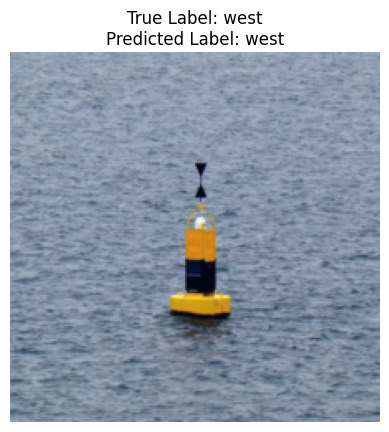

In [20]:
# Obtenir les noms des classes à partir du jeu de données
class_names = test_dataset.classes

# Appeler la fonction pour prédire et afficher une image
predict_and_display_image(model, test_dataset, class_names, device)

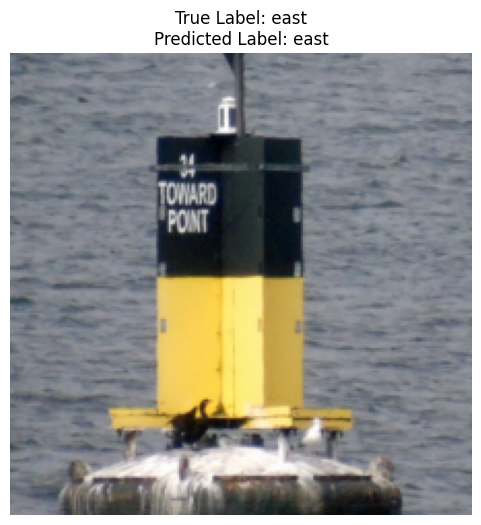

In [21]:
model.eval()

# On teste le réseau avec une image
image_pil = Image.open(adresse_img).convert('RGB')
true_label_idx = liste[0]
true_label_name = class_names[true_label_idx]

# Définir les transformations à appliquer à l'image (en utilisant les mêmes que pour le jeu de données)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Préparer l'image pour l'entrée du modèle (ajouter la dimension de batch)
input_tensor = transform(image_pil).unsqueeze(0).to(device)

# Effectuer la prédiction
with torch.no_grad():
    output = model(input_tensor)
    _, predicted_label_idx = torch.max(output, 1)
    predicted_label_name = class_names[predicted_label_idx.item()]

# Re-convertir l'image en numpy pour l'affichage (dé-normaliser si nécessaire)
# La transformation inclut la normalisation, nous devons donc l'inverser pour un affichage correct
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_for_display = input_tensor.squeeze().cpu().numpy().transpose((1, 2, 0)) # C, H, W vers H, W, C
img_for_display = std * img_for_display + mean
img_for_display = np.clip(img_for_display, 0, 1)

# Afficher l'image et la prédiction
plt.figure(figsize=(6, 6))
plt.imshow(img_for_display)
plt.title(f"True Label: {true_label_name}\nPredicted Label: {predicted_label_name}")
plt.axis('off')
plt.show()

### Statistiques de la classification

On calcule dans cette partie les métriques usuelles liées à la classification définies par :
$$ \text{Precision} = \frac{\text{TP}}{\text{TP}+\text{FP}} $$
$$ \text{Recall} = \frac{\text{TP}}{\text{TP}+\text{FN}} $$
$$ \text{F1-Score} = \frac{2}{\frac{1}{\text{Precision}}+\frac{1}{\text{Recall}}} $$
$$ \text{Accuracy} = \frac{\text{TP}+\text{TN}}{\text{TP}+\text{TN}+\text{FP}+\text{FN}} $$


In [22]:
# Exécution de l'évaluation
true_labels, predicted_labels = evaluate_full_test_set(model, test_loader, device)

Accuracy globale : 80.00%

Rapport de classification :
              precision    recall  f1-score   support

        east       1.00      0.33      0.50         6
       north       0.89      0.89      0.89         9
       south       1.00      1.00      1.00         5
        west       0.56      1.00      0.71         5

    accuracy                           0.80        25
   macro avg       0.86      0.81      0.78        25
weighted avg       0.87      0.80      0.78        25



Les scores finaux sont très satisfaisants par rapport aux autres approches.

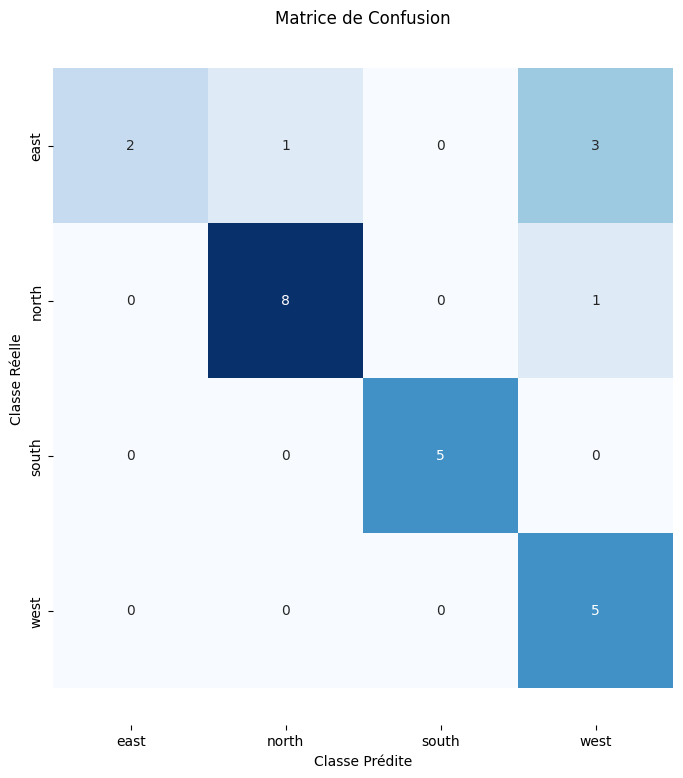

In [16]:
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Obtient les noms des classes à partir du dataset de test pour l'affichage de la matrice de confusion
classes = test_loader.dataset.classes

# Calcule la matrice de confusion en utilisant les étiquettes réelles et les étiquettes prédites
cm = confusion_matrix(true_labels, predicted_labels, labels=np.arange(len(classes)))

# Convertit en DataFrame pour une meilleure visualisation avec seaborn
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

# Affiche la matrice de confusion
plt.figure(figsize=(8, 9))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matrice de Confusion')
plt.xlabel('Classe Prédite')
plt.ylabel('Classe Réelle')
plt.axis('equal')
plt.show()